# Music21 Basics

Mike Cuthbert's Music21 library is a key resource for digital musicology.  It takes care of all the difficult work of finding notes, intervals and other important data about musical patterns.


- Get score
- Check metadata
- Find all voices, all notes
- Find particular notes (all of pitch class X, etc)



# Load Music 21
- Load libraries and namespaces


In [1]:
from music21 import *
import music21 as m21
import xml.etree.ElementTree as ET
# import a counter
from collections import Counter
from itertools import combinations
import pandas as pd

ns = {'mei': 'http://www.music-encoding.org/ns/mei'}


# Load Local File


In [12]:
path = 'Music_21_Files/prelude28-01.mei'
path


'Music_21_Files/prelude28-01.mei'

In [13]:
import verovio
from pathlib import Path

music_files_dir = Path("Music_21_Files")  # adjust if your notebook is elsewhere relative to this folder

krn_files = sorted(music_files_dir.glob("*.krn"))

tk = verovio.toolkit()

for krn_path in krn_files:
    ok = tk.loadFile(str(krn_path))
    if not ok:
        print(f"FAILED to load: {krn_path.name}")
        continue
    mei_data = tk.getMEI()
    mei_path = krn_path.with_suffix(".mei")
    mei_path.write_text(mei_data, encoding="utf-8")
    print(f"{krn_path.name} -> {mei_path.name}")


prelude28-01.krn -> prelude28-01.mei


In [14]:
import re
from music21 import converter


def krn_merge_staff_spines(text: str) -> str:
    """
    Rewrite parallel **kern spines that share a *staff# tag into real
    spine-split (*^) form, so Verovio/music21 render them as voices on
    one staff instead of separate staves.
    """
    lines = text.split('\n')

    excl_idx = None
    excl_tokens = None
    for i, line in enumerate(lines):
        tokens = line.split('\t')
        if tokens and all(t.startswith('**') for t in tokens):
            excl_idx = i
            excl_tokens = tokens
            break
    if excl_idx is None:
        return text

    ncols = len(excl_tokens)
    is_kern = [t == '**kern' for t in excl_tokens]

    staff_idx = None
    staff_tokens = None
    for i in range(excl_idx + 1, len(lines)):
        line = lines[i]
        if not line.startswith('*') or line.startswith('**'):
            break
        tokens = line.split('\t')
        if len(tokens) != ncols:
            continue
        if any(re.fullmatch(r'\*staff\d+', t) for t in tokens):
            staff_idx = i
            staff_tokens = tokens
            break

    if staff_idx is None:
        return text  # nothing to merge

    staff_num = [None] * ncols
    for idx, t in enumerate(staff_tokens):
        m = re.fullmatch(r'\*staff(\d+)', t)
        if m:
            staff_num[idx] = m.group(1)

    # group contiguous kern columns sharing the same staff number
    groups = []
    i = 0
    while i < ncols:
        if is_kern[i] and staff_num[i] is not None:
            j = i + 1
            while j < ncols and is_kern[j] and staff_num[j] == staff_num[i]:
                j += 1
            groups.append(list(range(i, j)))
            i = j
        else:
            groups.append([i])
            i += 1

    if all(len(g) == 1 for g in groups):
        return text  # no multi-spine staves to merge

    new_excl_row = [excl_tokens[g[0]] for g in groups]

    remaining = [len(g) - 1 for g in groups]
    cur_cols = [1] * len(groups)
    split_rows = []
    while any(r > 0 for r in remaining):
        row = []
        for gi in range(len(groups)):
            cnt = cur_cols[gi]
            if remaining[gi] > 0:
                row.extend(['*'] * (cnt - 1))
                row.append('*^')
                remaining[gi] -= 1
                cur_cols[gi] += 1
            else:
                row.extend(['*'] * cnt)
        split_rows.append(row)

    kept_tail_lines = [
        line for idx, line in enumerate(lines)
        if idx > excl_idx and idx != staff_idx
    ]

    new_lines = (
        lines[:excl_idx]
        + ['\t'.join(new_excl_row)]
        + ['\t'.join(r) for r in split_rows]
        + kept_tail_lines
    )
    return '\n'.join(new_lines)


def parse_krn(krn_path):
    """Parse a .krn file into music21, merging *staff-grouped spines onto shared staves."""
    with open(krn_path, encoding='utf-8') as f:
        text = f.read()
    merged_text = krn_merge_staff_spines(text)
    return converter.parseData(merged_text, format='humdrum')


In [15]:
def _promote_voice_clefs(score):
    """
    music21's humdrum parser drops the initial clef inside each Voice
    instead of the Measure when spines were merged via *^. The MusicXML
    writer only looks at Measure/Part level, so the clef gets lost and
    the staff silently defaults to treble. Hoist it back up.
    """
    for p in score.parts:
        measures = p.getElementsByClass('Measure')
        if not measures:
            continue
        m1 = measures[0]
        if m1.getElementsByClass('Clef'):
            continue
        for v in m1.voices:
            cl = v.getElementsByClass('Clef')
            if cl:
                m1.insert(0, cl[0])
                break


def parse_krn(krn_path):
    """Parse a .krn file into music21, merging *staff-grouped spines onto shared staves."""
    with open(krn_path, encoding='utf-8') as f:
        text = f.read()
    merged_text = krn_merge_staff_spines(text)
    score = converter.parseData(merged_text, format='humdrum')
    _promote_voice_clefs(score)
    return score


2


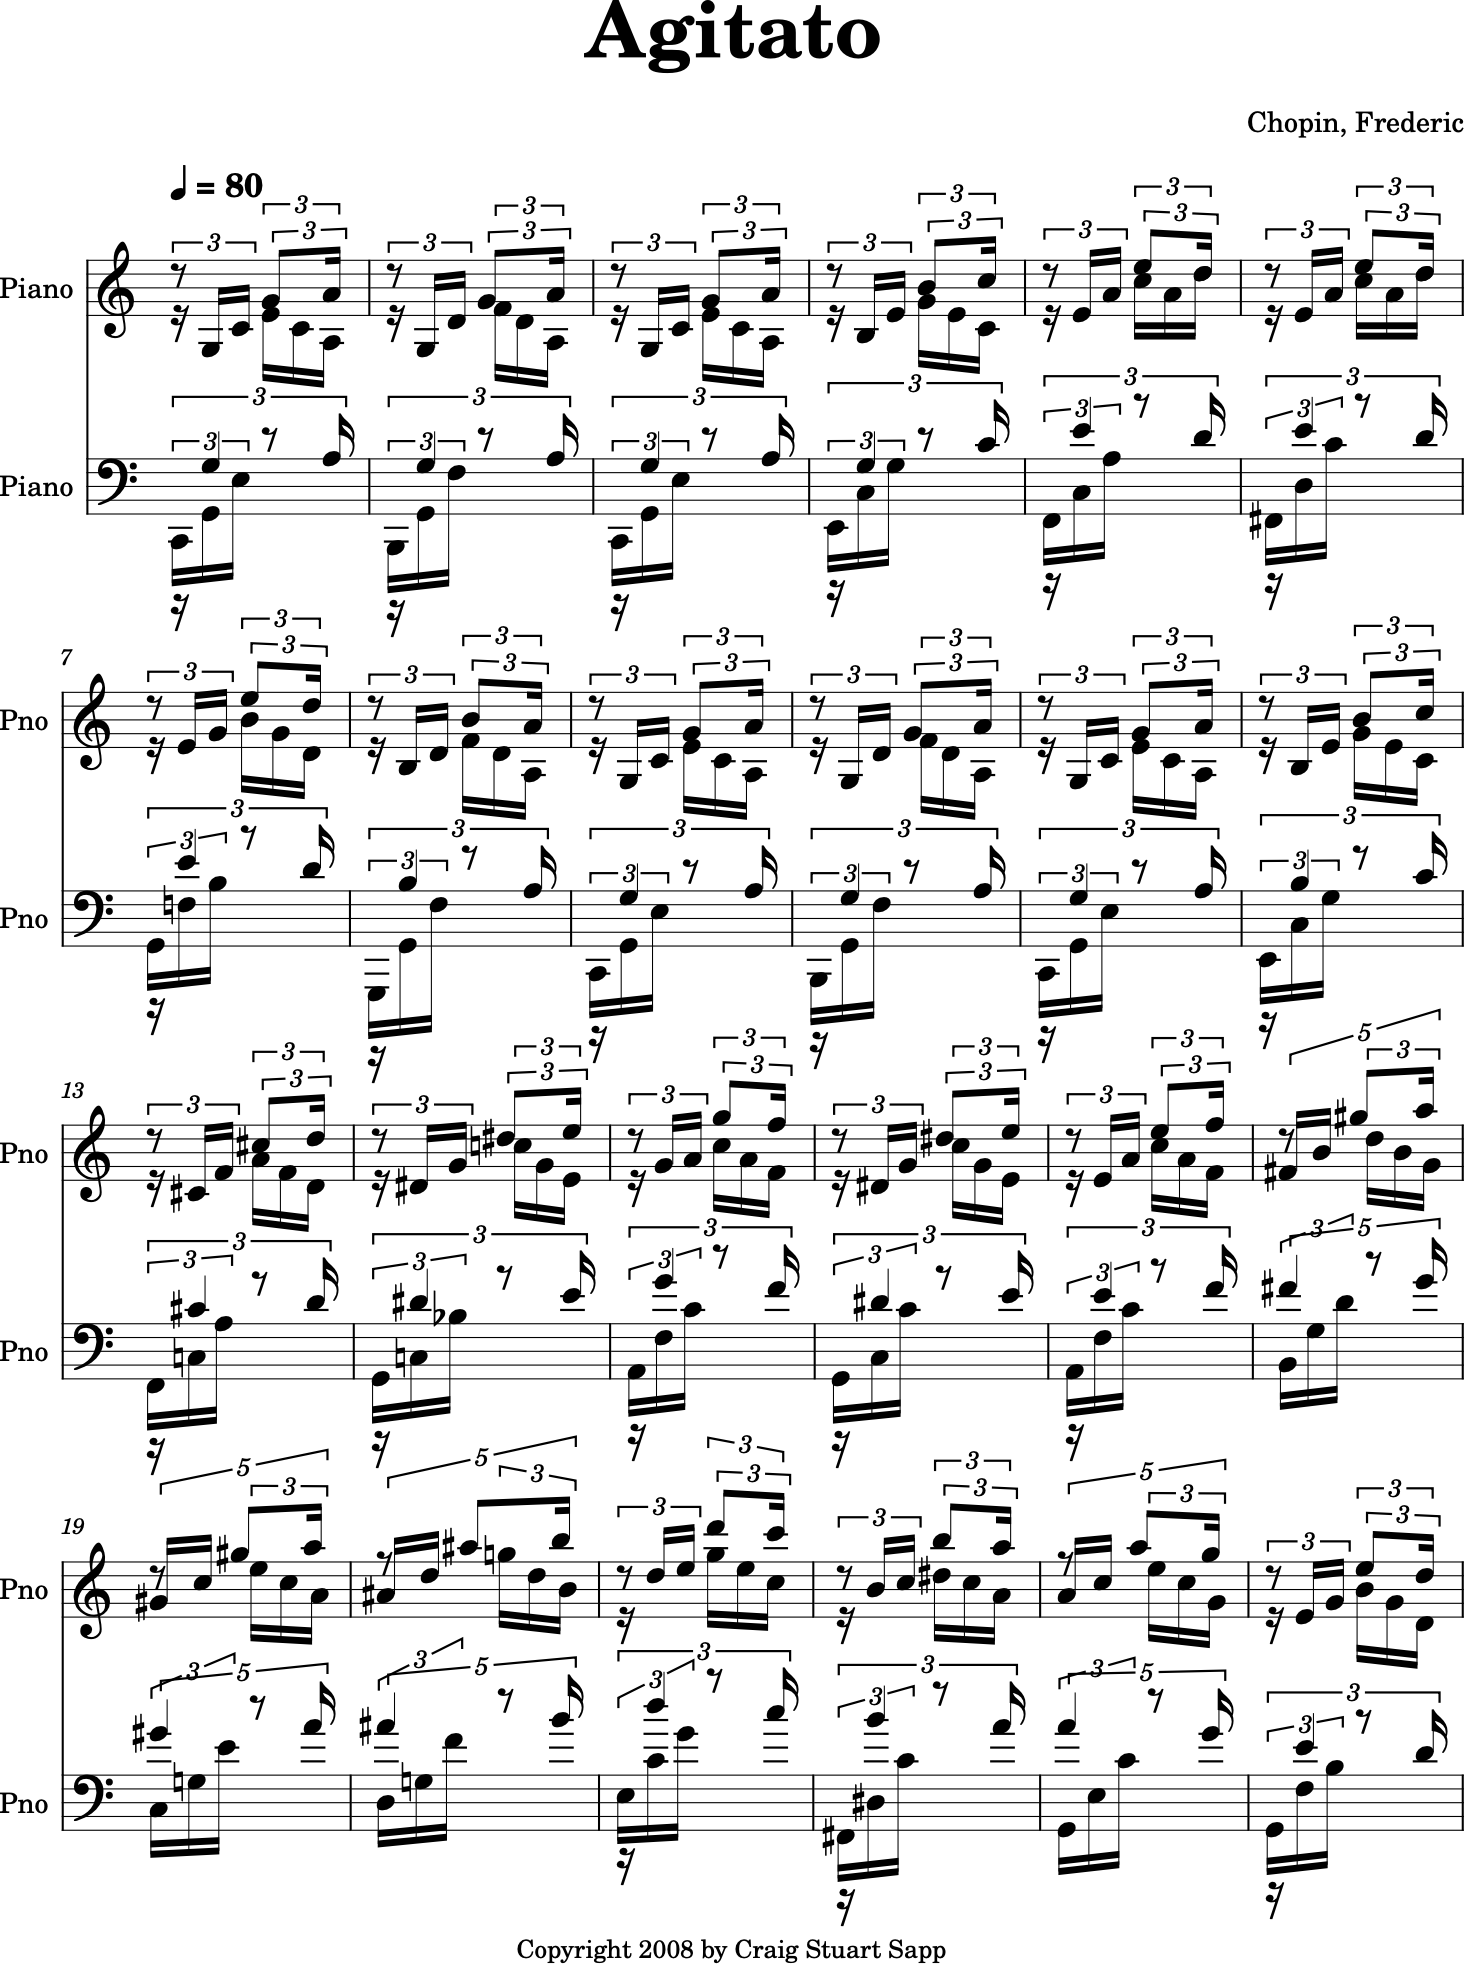

In [17]:
score = parse_krn("Music_21_Files/prelude28-01.krn")
print(len(score.parts))  # 2, not 4
score.show()


## Build Metadata and Show Parts and Notes

Music21 does not always read the metdata correctly, so we will find that information via the root of the XML tree, then add it to the Music21 `score` object.  

In [18]:
from music21 import environment
env = environment.Environment()
env['musicxmlPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'
env['musescoreDirectPNGPath'] = '/Applications/MuseScore 4.app/Contents/MacOS/mscore'


In [19]:
score = converter.parse(path, format='mei')


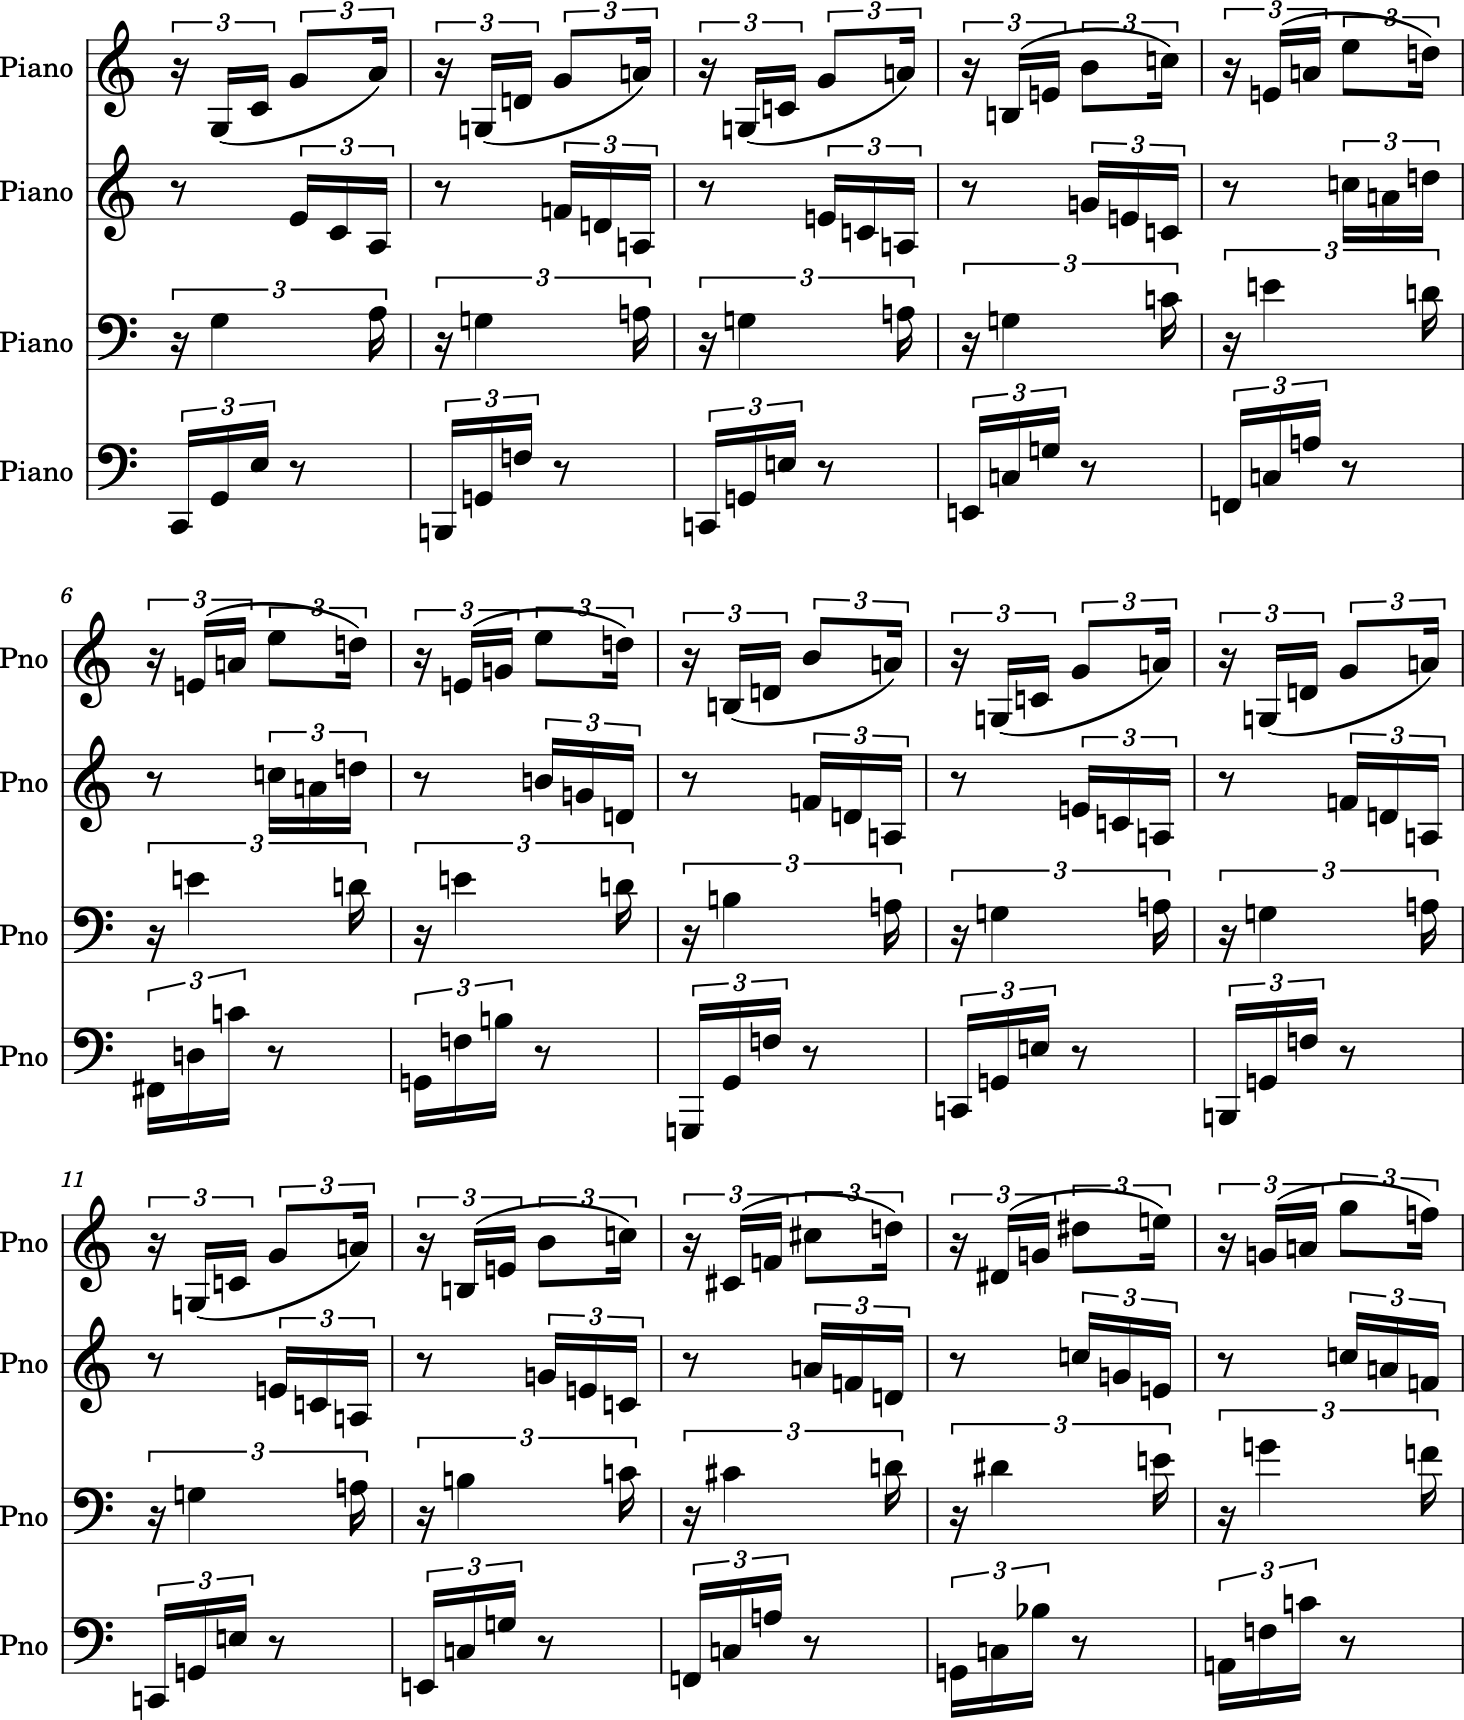

In [20]:
score.parts
score.show()

In [21]:
# deal with metadata directly from MEI file
tree = ET.parse(path)
root = tree.getroot()

ns = {'mei': 'http://www.music-encoding.org/ns/mei'}
title = root.findtext('.//mei:titleStmt/mei:title', namespaces=ns)
composer = root.find('.//mei:respStmt/mei:persName[@role="composer"]', namespaces=ns)

score = m21.converter.parse(path)
# assign the metadata to the score object
score.metadata.title = title.strip() if title else "Unknown Title"
score.metadata.composer = composer.text.strip() if composer is not None else "Unknown Composer"

# print details
print(score.metadata.composer)
print(score.metadata.title)


Unknown Composer
Prelude in C Minor, Op. 28, No. 1, Agitato



## List of Voice Parts

To list all the parts, we use `score.getElementsByClass(m21.stream.Part)`:



In [22]:
voice_parts = score.getElementsByClass(m21.stream.Part)
# now iterate over them and get the name of each one
for part in voice_parts:
  print(part.partName)

Piano
Piano
Piano
Piano


## Measures

- How many measures are in the score?



In [23]:
num_measures = len(score.parts[0].getElementsByClass(m21.stream.Measure))
print(f"Measures: {num_measures}")

Measures: 34


All parts should have the same count in a well-formed score, so checking `parts[0]` is sufficient. If you want to verify they match across parts:

```python
for part in score.parts:
    count = len(part.getElementsByClass(m21.stream.Measure))
    print(f"{part.partName or part.id}: {count} measures")

In [24]:
for part in score.parts:
    count = len(part.getElementsByClass(m21.stream.Measure))
    print(f"{part.partName or part.id}: {count} measures")


Piano: 34 measures
Piano: 34 measures
Piano: 34 measures
Piano: 34 measures


Just the first part, first 2 measures

In [25]:

score.parts[0].measures(1, 2).show('text')



{0.0} <music21.instrument.Piano '1: Piano'>
{0.0} <music21.stream.Measure 1 offset=0.0>
    {0.0} <music21.clef.TrebleClef>
    {0.0} <music21.stream.Voice 1>
        {0.0} <music21.note.Rest 1/6ql>
        {0.1667} <music21.note.Note G>
        {0.3333} <music21.note.Note C>
        {0.5} <music21.note.Note G>
        {0.8333} <music21.note.Note A>
{1.0} <music21.stream.Measure 2 offset=1.0>
    {0.0} <music21.stream.Voice 1>
        {0.0} <music21.note.Rest 1/6ql>
        {0.1667} <music21.note.Note G>
        {0.3333} <music21.note.Note D>
        {0.5} <music21.note.Note G>
        {0.8333} <music21.note.Note A>


# Notes from One Voice Part
- Define the variable `parts` and then showing where to obtain these with m21
- Define the variable for your staff by index number (`[0]` is the top voice, `[2]` is the third from the top, etc.


In [26]:
# all the staves:
voice_parts = score.getElementsByClass(m21.stream.Part)

# specify the part; the top part is index 0, the second from the top is index 1, etc
selected_part = voice_parts[0]
# now the notes from that selected part
notes_selected_part = selected_part.flat.getElementsByClass(['Note'])
# and now we can iterate over those notes and print them--in this case just the first 10 notes to save space
for note in notes_selected_part[:10]:
  print(note)


<music21.note.Note G>
<music21.note.Note C>
<music21.note.Note G>
<music21.note.Note A>
<music21.note.Note G>
<music21.note.Note D>
<music21.note.Note G>
<music21.note.Note A>
<music21.note.Note G>
<music21.note.Note C>


## "Notes" are Pitch Classes
- looking for all the notes in a given part
- `[X]` is index of the given part
- must include "flat" to get all the notes, not just the ones in the first measure
- iterate over those notes and print them

In [27]:
# all the staves:
voice_parts = score.getElementsByClass(m21.stream.Part)

# specify the part; the top part is index 0, the second from the top is index 1, etc
selected_part = voice_parts[0]
notes_selected_part = selected_part.flat.getElementsByClass(['Note'])
# create a list where we can store the list of notes
selected_notes_list = []

# now we iterate of the note objects and return the `name` attribute of each note, which is JUST the pitch class (no octave number)
for each_note in notes_selected_part:
    # here we get the `name` attribute of the note, which is JUST the pitch class
    selected_notes_list.append(each_note.name)

print(selected_notes_list)



['G', 'C', 'G', 'A', 'G', 'D', 'G', 'A', 'G', 'C', 'G', 'A', 'B', 'E', 'B', 'C', 'E', 'A', 'E', 'D', 'E', 'A', 'E', 'D', 'E', 'G', 'E', 'D', 'B', 'D', 'B', 'A', 'G', 'C', 'G', 'A', 'G', 'D', 'G', 'A', 'G', 'C', 'G', 'A', 'B', 'E', 'B', 'C', 'C#', 'F', 'C#', 'D', 'D#', 'G', 'D#', 'E', 'G', 'A', 'G', 'F', 'D#', 'G', 'D#', 'E', 'E', 'A', 'E', 'F', 'F#', 'B', 'G#', 'A', 'G#', 'C', 'G#', 'A', 'A#', 'D', 'A#', 'B', 'D', 'E', 'D', 'C', 'B', 'C', 'B', 'A', 'A', 'C', 'A', 'G', 'E', 'G', 'E', 'D', 'G', 'C', 'G', 'A', 'E', 'G', 'E', 'D', 'G', 'C', 'G', 'A', 'E', 'G', 'E', 'D', 'C', 'F', 'C', 'C', 'C', 'F', 'C', 'C', 'C', 'F', 'C', 'C', 'C', 'F', 'C']


## Now the Specific Notes as Pitch Class plus Octave Number
- specify the part; the top part is index 0, the second from the top is index 1, etc
- now the notes from that selected part
- and now we can iterate over those notes and print them

In [28]:
# all the staves:
voice_parts = score.getElementsByClass(m21.stream.Part)

# specify the part; the top part is index 0, the second from the top is index 1, etc
selected_part = voice_parts[0]
selected_part = voice_parts[0]
# the notes in that part
notes_selected_part = selected_part.flat.getElementsByClass(['Note'])
# create a list where we can store the list of notes
selected_notes_list = []
for each_note in notes_selected_part:
    # here we get the `nameWithOctave` attribute of the note, which is the pitch class plus the octave number
    selected_notes_list.append(each_note.nameWithOctave)

print(selected_notes_list)

['G3', 'C4', 'G4', 'A4', 'G3', 'D4', 'G4', 'A4', 'G3', 'C4', 'G4', 'A4', 'B3', 'E4', 'B4', 'C5', 'E4', 'A4', 'E5', 'D5', 'E4', 'A4', 'E5', 'D5', 'E4', 'G4', 'E5', 'D5', 'B3', 'D4', 'B4', 'A4', 'G3', 'C4', 'G4', 'A4', 'G3', 'D4', 'G4', 'A4', 'G3', 'C4', 'G4', 'A4', 'B3', 'E4', 'B4', 'C5', 'C#4', 'F4', 'C#5', 'D5', 'D#4', 'G4', 'D#5', 'E5', 'G4', 'A4', 'G5', 'F5', 'D#4', 'G4', 'D#5', 'E5', 'E4', 'A4', 'E5', 'F5', 'F#4', 'B4', 'G#5', 'A5', 'G#4', 'C5', 'G#5', 'A5', 'A#4', 'D5', 'A#5', 'B5', 'D5', 'E5', 'D6', 'C6', 'B4', 'C5', 'B5', 'A5', 'A4', 'C5', 'A5', 'G5', 'E4', 'G4', 'E5', 'D5', 'G3', 'C4', 'G4', 'A4', 'E4', 'G4', 'E5', 'D5', 'G3', 'C4', 'G4', 'A4', 'E4', 'G4', 'E5', 'D5', 'C4', 'F4', 'C5', 'C5', 'C4', 'F4', 'C5', 'C5', 'C4', 'F4', 'C5', 'C5', 'C4', 'F4', 'C5']


## Which Notes in the First Measure?



In [29]:
# specify measure range; this is the first measure only; change to (1, 2) for the first two measures, etc.
measure_range = (1, 1) 
# now get all the notes in one line fof code; we specify the part, then the measure range, then we get all the notes in that measure range
notes_in_given_measure_range = score.parts[0].measures(measure_range[0], measure_range[1]).flat.getElementsByClass(['Note'])

# empty list to store the notes in the measure range
notes_in_measure = []
for each_note in notes_in_given_measure_range:
    # here we get the `nameWithOctave` attribute of the note, which is the pitch class plus the octave number
    notes_in_measure.append(each_note.nameWithOctave)

print(notes_in_measure)


['G3', 'C4', 'G4', 'A4']


## Durations

Durations are recorded in terms of quarter notes, so a whole note is `4.0`, a half note is `2.0`, a quarter note is `1.0`, an eighth note is `0.5`, etc.



In [30]:
# here we get all the notes (as before)

notes_in_part = score.parts[0].flatten().getElementsByClass(m21.note.Note)

# iterate over the notes and print their name with octave and their duration in quarter notes--also just the first ten to save space
for note in notes_in_part[:10]:
    duration = note.quarterLength
    print(f"{note.nameWithOctave}: {duration}")

G3: 1/6
C4: 1/6
G4: 1/3
A4: 1/6
G3: 1/6
D4: 1/6
G4: 1/3
A4: 1/6
G3: 1/6
C4: 1/6


In [31]:
# test for note durations with specific duration (half notes)

notes_in_part = score.parts[0].flatten().getElementsByClass(m21.note.Note)

half_note_names = [n.name for n in notes_in_part if n.quarterLength == 2.0]
print(half_note_names)


[]


In [32]:
# finding the measure numbers in which those half notes occur
notes_in_part = score.parts[0].flatten().getElementsByClass(m21.note.Note)

for n in notes_in_part:
    if n.quarterLength == 2.0:
        print(f"m.{n.measureNumber}  {n.nameWithOctave}")

## Rests are not the Same as Notes!

- `note` objects are from the class `m21.note.Note`
- `rest` objects are from the class `m21.note.Rest` 


If you just ask for "all the notes", you will get only the note objects, and not the rest objects. So if you want to find all the notes, you need to specify that class!


In [33]:
# get all the rests in the entire score
rests_in_part = score.flatten().getElementsByClass(m21.note.Rest)
# create a list to store the durations of the rests
rest_list = []
# iterate over the rests and get their durations in quarter notes
for rest in rests_in_part:
    rest_list.append(rest.duration.quarterLength)

print(rest_list)
print(len(rest_list))
#print(rest_list[0])


[Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, 0.5, 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, 0.5, 0.5, 0.5, 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6), 0.5, Fraction(1, 6),

## Key Attributes of a Music21 Note Object

### Discover All Attributes

Run this to see all the attributes of the note object. The attributes are grouped into categories below, but this will show you everything that is available to you for a note object.
```python
n = score.parts[0].flatten().getElementsByClass(m21.note.Note)[0]
print([attr for attr in dir(n) if not attr.startswith('_')])
```

### Pitch
| Attribute | Description | Example |
|---|---|---|
| `n.name` | Pitch name without octave | `"C"`, `"D#"` |
| `n.nameWithOctave` | Pitch name with octave | `"C4"` |
| `n.pitch` | Full Pitch object | `<music21.pitch.Pitch C4>` |
| `n.octave` | Octave number | `4` |
| `n.midi` | MIDI pitch number | `60` |
| `n.ps` | Pitch space as float | `60.0` |
| `n.step` | Diatonic letter only | `"C"`, `"D"` |
| `n.accidental` | Accidental object or None | `<music21.pitch.Accidental sharp>` |

### Duration
| Attribute | Description | Example |
|---|---|---|
| `n.quarterLength` | Duration in quarter notes | `2.0` (half note) |
| `n.duration.type` | Duration name | `"whole"`, `"half"`, `"quarter"` |
| `n.duration.dots` | Augmentation dots | `1` (dotted), `0` (plain) |

### Position
| Attribute | Description | Example |
|---|---|---|
| `n.offset` | Beat offset from container start | `4.0` |
| `n.measureNumber` | Measure number | `3` |
| `n.beat` | Beat within the measure | `1.0` |
| `n.beatStrength` | Metric weight | `1.0` (downbeat), `0.25` (weak) |

### Articulation & Expression
| Attribute | Description |
|---|---|
| `n.articulations` | List of Articulation objects (staccato, accent, etc.) |
| `n.expressions` | List of Expression objects (trill, fermata, etc.) |
| `n.tie` | Tie object or None |
| `n.lyric` / `n.lyrics` | Text underlay (single string or list) |

### Miscellaneous
| Attribute | Description |
|---|---|
| `n.stemDirection` | `"up"`, `"down"`, `"noStem"` |
| `n.notehead` | Notehead shape string |
| `n.id` | Unique element ID |


# Pitch (Note in a particular Octave)
- here we look for notes in specific octaves, like `4`.



In [34]:
notes_in_octave = [n for n in score.parts[0].flatten().getElementsByClass(m21.note.Note)
                   if n.octave == 4]

# just the first ten notes in octave 4 to save space
for n in notes_in_octave[:10]:
    print(f"m.{n.measureNumber}  {n.nameWithOctave}")


m.1  C4
m.1  G4
m.1  A4
m.2  D4
m.2  G4
m.2  A4
m.3  C4
m.3  G4
m.3  A4
m.4  E4


In [35]:
# count the notes in a given octave

# specify the octave we want to look at
selected_octave = 4
# get the notes that match the condition, using list comprehension
selected_octave_tones = [n.name for n in score.parts[0].flatten().getElementsByClass(m21.note.Note) if n.octave == selected_octave]

# pass these to the counter function
octave_counts = Counter(selected_octave_tones)

octave_counts_df = pd.DataFrame.from_dict(octave_counts, orient='index', columns=['Count'])
octave_counts_df.index.name = 'Pitch Class'
octave_counts_df.reset_index(inplace=True)
octave_counts_df


,Pitch Class,Count
0,C,10
1,G,15
2,A,14
3,D,3
4,E,9
5,B,5
6,C#,1
7,F,5
8,D#,2
9,F#,1


# Intervals
-`pitch` is the module (a collection of methods and classes); `Pitch` is the class (data structure)
- `interval` is part of the `pitch` module (it's a submodule), and has the method `notesToInterval`.  
- Here `Interval` is another class (data structure), and `interval` is another module


## Melodic Interval Attributes

| Attribute | Example | Description |
|---|---|---|
| `directedName` | `"-M2"` | Direction + quality + size |
| `name` | `"M2"` | Quality + size, no direction |
| `semitones` | `-2` | Raw half-steps (signed) |
| `generic.directed` | `-2` | Diatonic steps (signed) |

### Directed Name Format
`[direction][quality][size]`

| Part | Values | Example |
|---|---|---|
| Direction | `-` (down), none (up) | `-` |
| Quality | `P` perfect, `M` major, `m` minor, `A` augmented, `d` diminished | `M` |
| Size | Diatonic interval number | `2` |

So `-M2` = descending major second, `P5` = ascending perfect fifth.


In [36]:
# the notes

a = m21.pitch.Pitch('C4')
b = m21.pitch.Pitch('G4')

# the interval between those two notes in as interval + quality
ivl = interval.Interval(a, b)
print(ivl.semitones)      # 7
print(ivl.directedName)   # P5

7
P5


In [37]:
# count all the intervals between adjacent notes in all parts

parts = score.getElementsByClass(m21.stream.Part)

# empty list to store the intervals
list_intervals = []

# iterate over the parts, get the notes in each part, and then get the intervals between adjacent notes
for part in parts:
    notes = list(part.flatten().getElementsByClass(m21.note.Note))

    intervals = [interval.Interval(notes[i], notes[i+1]).directedName
                for i in range(len(notes) - 1)]
    # add the intervals from this part to the overall list of intervals
    list_intervals.extend(intervals)
# count them
melodic_intervals_df = pd.DataFrame.from_dict(Counter(list_intervals), orient='index', columns=['Count'])
melodic_intervals_df.index.name = 'Interval'
melodic_intervals_df.reset_index(inplace=True)
melodic_intervals_df

,Interval,Count
0,P4,29
1,P5,51
2,M2,23
3,M-9,11
4,m-7,4
5,m2,18
6,m-6,1
7,M-2,30
8,m3,10
9,M6,21


## Harmonic Intervals

For harmonic intervals between two simultaneous voices, chordify() is the standard approach — it collapses all parts into chords at each offset:

In [38]:
chords = score.chordify()

harmonic_intervals = []
for chord in chords.flatten().getElementsByClass(m21.chord.Chord):
    # compare adjacent pitches within each chord (bottom to top)
    pitches = chord.pitches  # sorted low to high
    for i in range(len(pitches) - 1):
        ivl = interval.Interval(pitches[i], pitches[i+1]).directedName
        harmonic_intervals.append(ivl)

counts = Counter(harmonic_intervals)
harmonic_intervals_df = pd.DataFrame.from_dict(counts, orient='index', columns=['Count'])
harmonic_intervals_df.index.name = 'Interval'
harmonic_intervals_df.reset_index(inplace=True)
harmonic_intervals_df

,Interval,Count
0,P8,42
1,m3,38
2,P4,53
3,M6,24
4,P5,32
5,M2,8
6,m7,5
7,M3,18
8,M10,2
9,m6,8


##  Lyrics




Let's get a score with lyrics:

In [40]:
path = "Music_21_Files/Morley_1595_01_Go_ye_my_canzonettes.mei"
# deal with metadata directly from MEI file
tree = ET.parse(path)
root = tree.getroot()

ns = {'mei': 'http://www.music-encoding.org/ns/mei'}
title = root.findtext('.//mei:titleStmt/mei:title', namespaces=ns)
composer = root.find('.//mei:respStmt/mei:persName[@role="composer"]', namespaces=ns)

score = m21.converter.parse(path)
# assign the metadata to the score object
score.metadata.title = title.strip() if title else "Unknown Title"
score.metadata.composer = composer.text.strip() if composer is not None else "Unknown Composer"

# print details
print(score.metadata.composer)
print(score.metadata.title)

for part in score.parts:
    print(f"\n--- {part.partName or part.id} ---")
    lyrics = [n.lyric.replace("\n", "").replace("-", "").strip()
              for n in part.flatten().getElementsByClass(m21.note.Note)
              if n.lyric and n.lyric.strip()]
    print(" ".join(lyrics))



Morley, Thomas
Go ye my canzonettes, RISM A/I: M 3701.  No. 1

--- Soprano ---
Goe yee my Can zo nets to my deer dar ling, goe yee my Can zo nets to my deer dar ling, goe yee my Can zo nets to my deer dar ling, to my deer dar ling, and with your gen tlr dain tie sweet ac cen tings, de sire hir to vouch safe these my la men tings, de sire hir to vouch safe these my la men tings, and with a crow net, of hir rayes su per nall, t'a dorne your locks and make your name e ter nal, t'a dorne your locks and make yout name e ter nall, and with a crow net of hir rayes su per nall, t'a dorne your locks and make your name e ter nal, t'a dorne yout locks and make your name e ter nall.

--- Soprano ---
Goe yee my Can zo nets to my deer dar ling, deer dar ling, goe yee my Can zo nets to my deer dar ling, to my deer dar ling, and with your gen tle dain tie sweet ac cen tings, de sire hir to vouch safe these my la men tings, de sire hir to vouch safe these my la men tings, and with a crow net, of hir ra